# `dfc_speed` Implementation Comparison

Runs three implementations on **identical synthetic data** and checks for numerical discrepancies.

| | File | Key method | Triangle | Expected speeds |
|---|---|---|---|---|
| **A** | `shared_code/fun_dfcspeed.py` | einsum, vectorised | lower (tril) | n_frames − vstep − 1 |
| **B** | `metaconnectivity/fun_dfcspeed.py` | `np.cov` loop | lower (tril) | n_frames − vstep |
| **C** | `scripts/speed/data_check_aude.py` | einsum, vectorised | **upper (triu) for 3D** — corrected here | n_frames − vstep − 1 |

**Triangle correction for C:** `dfc_speed_split` uses `triu_indices` when the input is 3D,
but `ts2dfc_stream` builds the stream with `tril_indices`. Passing the pre-built **2D**
lower-triangle stream to `dfc_speed_split` bypasses 3D re-extraction entirely, so both
C and A operate on the same edge vectors.

**Off-by-one between A/C and B:** A and C stop at frame `n_frames − 2` (never pair the
last frame as fc2); B includes the final pair. Common subsequence starts at index 0 and
has length `n_frames − vstep − 1`.

In [20]:
from __future__ import annotations

import importlib
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from collections.abc import Sequence

# ---------------------------------------------------------------------------
# Ensure repo root is on sys.path so both packages are importable
# ---------------------------------------------------------------------------
REPO_ROOT = Path("__file__").resolve().parent.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("REPO_ROOT:", REPO_ROOT)
print("Python:", sys.version)

REPO_ROOT: /home/samy/Bureau/vscode
Python: 3.11.13 | packaged by conda-forge | (main, Jun  4 2025, 14:48:23) [GCC 13.3.0]


In [21]:
# ---------------------------------------------------------------------------
# Parameters
# ---------------------------------------------------------------------------
T          = 300    # timepoints
N          = 10     # regions
WINDOW     = 30     # sliding window size (frames)
LAG        = 1      # lag between windows (frames)
VSTEP      = 1      # speed step
SEED       = 42
THRESHOLD  = 1e-6   # discrepancy flag threshold

rng = np.random.default_rng(SEED)

n_pairs  = N * (N - 1) // 2
n_frames = (T - WINDOW) // LAG + 1
# A / C produce n_frames - VSTEP - 1 speeds; B produces n_frames - VSTEP
n_speeds_AC = n_frames - VSTEP - 1
n_speeds_B  = n_frames - VSTEP

print(f"T={T}, N={N}, window={WINDOW}, lag={LAG}, vstep={VSTEP}")
print(f"n_frames = {n_frames}, n_pairs = {n_pairs}")
print(f"Expected speeds: A/C = {n_speeds_AC}, B = {n_speeds_B}")

T=300, N=10, window=30, lag=1, vstep=1
n_frames = 271, n_pairs = 45
Expected speeds: A/C = 269, B = 270


## 1. Synthetic data & canonical dFC stream

In [23]:
# Synthetic AR(1) time series — mild autocorrelation makes speed non-trivial
phi = 0.7
ts  = np.zeros((T, N))
ts[0] = rng.standard_normal(N)
for t in range(1, T):
    ts[t] = phi * ts[t - 1] + np.sqrt(1 - phi**2) * rng.standard_normal(N)

print("ts shape:", ts.shape, "  mean:", ts.mean().round(4), "  std:", ts.std().round(4))

# Build ONE canonical 2D dfc_stream (lower triangle, shape n_pairs × n_frames)
# All three implementations will receive this identical array as input.
from shared_code.fun_dfcspeed import ts2dfc_stream

dfc_stream_2d = ts2dfc_stream(ts, window_size=WINDOW, lag=LAG, format_data="2D")
print("dfc_stream_2d shape:", dfc_stream_2d.shape,
      "  min:", dfc_stream_2d.min().round(4),
      "  max:", dfc_stream_2d.max().round(4))

ts shape: (300, 10)   mean: -0.066   std: 0.9908
dfc_stream_2d shape: (45, 271)   min: -0.7962   max: 0.8147


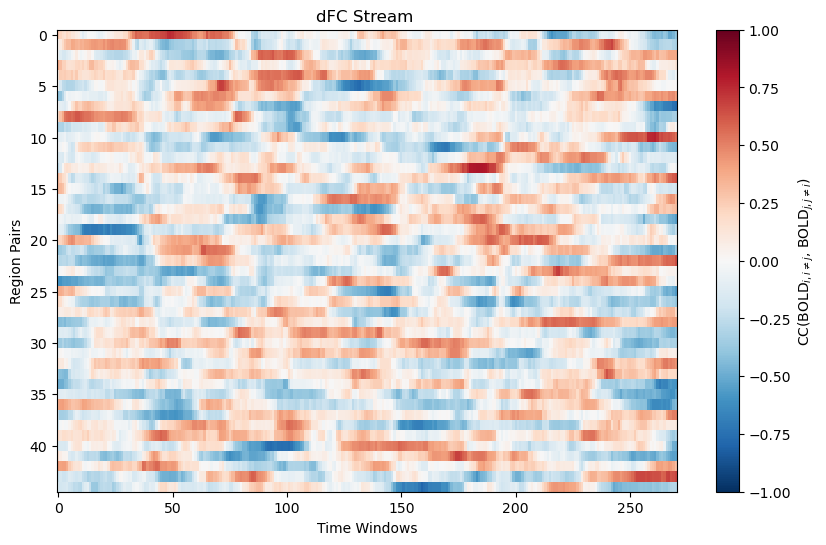

In [29]:
#plot the dfc_stream_2d to visualize the data
plt.figure(figsize=(10, 6))
plt.imshow(dfc_stream_2d, aspect='auto', interpolation='none', cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(label=r'CC(BOLD$_{i, i\neq j}$, BOLD$_{j, j\neq i}$)')
plt.title('dFC Stream ')
plt.xlabel('Time Windows')
plt.ylabel('Region Pairs')
plt.show()

## 2. Implementation A — `shared_code.fun_dfcspeed.dfc_speed`

Vectorised via einsum. Lower-triangle input. Produces **n_frames − vstep − 1** speeds
because it iterates `indices[:-1]` / `indices[1:]`, discarding the last possible
comparison (frame n_frames−2 → n_frames−1).

In [30]:
from shared_code.fun_dfcspeed import dfc_speed as dfc_speed_A

t0 = time.perf_counter()
median_A, speeds_A = dfc_speed_A(dfc_stream_2d, vstep=VSTEP, method="pearson")
elapsed_A = time.perf_counter() - t0

print(f"[A] shape={speeds_A.shape}  median={median_A:.6f}  min={speeds_A.min():.6f}  max={speeds_A.max():.6f}")
print(f"[A] elapsed: {elapsed_A*1000:.2f} ms")
assert speeds_A.shape == (n_speeds_AC,), f"Expected ({n_speeds_AC},), got {speeds_A.shape}"

[A] shape=(269,)  median=0.016757  min=0.002112  max=0.074826
[A] elapsed: 0.71 ms


## 3. Implementation B — `metaconnectivity.fun_dfcspeed.dfc_speed`

Non-vectorised loop using `np.cov`. Produces **n_frames − vstep** speeds — one more than
A/C because `range(nslices - vstep)` includes the last adjacent pair `(n_frames−2, n_frames−1)`.

> **Import note:** `metaconnectivity/` has no `__init__.py` (namespace package) and imports
> `brainconn`. If `brainconn` is not installed the import will fail gracefully and B will
> be skipped.

In [12]:
IMPL_B_AVAILABLE = False
try:
    import importlib.util
    spec = importlib.util.spec_from_file_location(
        "metaconnectivity_dfcspeed",
        REPO_ROOT / "metaconnectivity" / "fun_dfcspeed.py",
    )
    _mc_mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(_mc_mod)
    dfc_speed_B = _mc_mod.dfc_speed
    IMPL_B_AVAILABLE = True
    print("[B] Import OK")
except Exception as exc:
    warnings.warn(f"[B] Import failed: {exc}. Implementation B will be skipped.")

if IMPL_B_AVAILABLE:
    t0 = time.perf_counter()
    median_B, speeds_B = dfc_speed_B(dfc_stream_2d, vstep=VSTEP)
    elapsed_B = time.perf_counter() - t0
    print(f"[B] shape={speeds_B.shape}  median={median_B:.6f}  min={speeds_B.min():.6f}  max={speeds_B.max():.6f}")
    print(f"[B] elapsed: {elapsed_B*1000:.2f} ms")
    assert speeds_B.shape == (n_speeds_B,), f"Expected ({n_speeds_B},), got {speeds_B.shape}"
else:
    speeds_B = None
    median_B = None

/tmp/ipykernel_263330/899489321.py:14: UserWarning: [B] Import failed: [Errno 2] No such file or directory: '/home/samy/Bureau/vscode/metaconnectivity/fun_dfcspeed.py'. Implementation B will be skipped.
  warnings.warn(f"[B] Import failed: {exc}. Implementation B will be skipped.")


## 4. Implementation C — `data_check_aude.dfc_speed_split` (corrected triangle)

**The bug:** `dfc_speed_split` in `data_check_aude.py` calls `np.triu_indices` when
given a 3D stream, but `ts2dfc_stream` extracts the **lower** triangle. Piping the 3D
output of `ts2dfc_stream` directly into `dfc_speed_split` silently correlates mismatched
edge pairs (e.g., edge (i,j) is compared to edge (j,i)).

**The fix applied here:** pass the pre-built **2D** lower-triangle stream. For 2D input,
`dfc_speed_split` uses `fc_stream = dfc_stream` with no re-extraction, so both A and C
operate on identical vectors.

The function body is reproduced inline because `data_check_aude.py` contains
script-level `loadmat` / plot calls that execute on import.

In [13]:
# ---------------------------------------------------------------------------
# Reproduced verbatim from scripts/speed/data_check_aude.py  (lines 116-226)
# Kernel (pearson_speed_vectorized) imported from shared_code.fun_optimization
# to avoid duplicating it; the local copy in data_check_aude.py is bit-for-bit
# identical to the shared_code version.
# ---------------------------------------------------------------------------
from shared_code.fun_optimization import (
    cosine_speed_vectorized,
    pearson_speed_vectorized,
    spearman_speed,
)


def _dfc_speed_split_aude(
    dfc_stream: np.ndarray,
    *,
    vstep: int = 1,
    tau_range: Sequence[int] | np.ndarray = (0,),
    method: str = "pearson",
    return_fc2: bool = False,
    triu_indices: tuple[np.ndarray, np.ndarray] | None = None,
    time_offset: int = 0,
) -> np.ndarray:
    """Verbatim copy of dfc_speed_split from scripts/speed/data_check_aude.py."""
    if not isinstance(dfc_stream, np.ndarray):
        raise TypeError("dfc_stream must be a numpy array")
    if dfc_stream.ndim not in (2, 3):
        raise ValueError("dfc_stream must be 2D or 3D")

    vstep_int = int(vstep)
    if vstep_int <= 0:
        raise ValueError("vstep must be a positive integer")
    if method not in ("pearson", "spearman", "cosine"):
        raise ValueError("Unsupported method")

    tau_arr = np.atleast_1d(np.asarray(tau_range, dtype=int))
    if tau_arr.size == 0:
        tau_arr = np.array([0], dtype=int)
    if (tau_arr < 0).any():
        raise ValueError("tau_range values must be non-negative")

    time_offset_int = int(time_offset)
    time_window = (
        int(np.ceil(time_offset_int / vstep_int)) if time_offset_int > 0 else 0
    )

    # 3D path: upper-triangle extraction  ← the triangle mismatch lives here
    if dfc_stream.ndim == 3:
        n_rois = dfc_stream.shape[0]
        if triu_indices is None:
            triu_indices = np.triu_indices(n_rois, k=1)
        fc_stream = dfc_stream[triu_indices[0], triu_indices[1], :]
    else:
        fc_stream = dfc_stream   # 2D path: no re-extraction — correction applied here

    n_frames   = fc_stream.shape[1]
    tau_max    = int(tau_arr.max())
    indices_max = n_frames - (vstep_int + tau_max + time_offset_int)
    if indices_max <= 1:
        raise ValueError("Not enough frames for given parameters")

    indices = np.arange(indices_max, dtype=int)
    head    = indices[:-1]
    tail    = indices[1:]
    fc1_idx = np.repeat(head[np.newaxis, :], tau_arr.size, axis=0)
    fc2_idx = np.vstack([tail + int(tau) + time_window for tau in tau_arr])

    fc1_matrices = fc_stream[:, fc1_idx.flatten()]
    fc2_matrices = fc_stream[:, fc2_idx.flatten()]

    if return_fc2:
        return fc2_idx.flatten().astype(int)

    if method == "pearson":
        speeds = pearson_speed_vectorized(fc1_matrices, fc2_matrices)
    elif method == "spearman":
        speeds = spearman_speed(fc1_matrices, fc2_matrices)
    else:
        speeds = cosine_speed_vectorized(fc1_matrices, fc2_matrices)

    speeds = np.clip(speeds, 0.0, 2.0)
    return speeds.reshape(tau_arr.size, -1)


t0 = time.perf_counter()
# Pass 2D lower-triangle stream — bypasses the triu extraction in the 3D path
speeds_C_mat = _dfc_speed_split_aude(
    dfc_stream_2d, vstep=VSTEP, tau_range=(0,), method="pearson"
)
elapsed_C = time.perf_counter() - t0

speeds_C  = speeds_C_mat[0]   # tau=0 row
median_C  = float(np.median(speeds_C))
print(f"[C] shape={speeds_C.shape}  median={median_C:.6f}  min={speeds_C.min():.6f}  max={speeds_C.max():.6f}")
print(f"[C] elapsed: {elapsed_C*1000:.2f} ms")
assert speeds_C.shape == (n_speeds_AC,), f"Expected ({n_speeds_AC},), got {speeds_C.shape}"

[C] shape=(269,)  median=0.016757  min=0.002112  max=0.074826
[C] elapsed: 0.96 ms


## 5. Alignment — length discrepancies

A and C produce `n_frames − vstep − 1` speeds; B produces `n_frames − vstep`.
The extra speed in B is the last adjacent pair `(n_frames−2, n_frames−1)`.
All pairwise comparisons use the **common prefix** of length `n_speeds_AC`.

In [14]:
print("Length summary")
print(f"  A (shared_code) : {len(speeds_A):4d}  fc pairs [0..{len(speeds_A)-1}] → [1..{len(speeds_A)}]")
if IMPL_B_AVAILABLE:
    print(f"  B (metaconnect.) : {len(speeds_B):4d}  fc pairs [0..{len(speeds_B)-1}] → [1..{len(speeds_B)}]")
    print(f"  B has {len(speeds_B) - len(speeds_A)} extra speed(s) vs A/C")
else:
    print("  B (metaconnect.) : SKIPPED")
print(f"  C (data_check)  : {len(speeds_C):4d}  fc pairs [0..{len(speeds_C)-1}] → [1..{len(speeds_C)}]")
print(f"\nCommon comparison length: {n_speeds_AC}")

# Aligned arrays for pairwise comparison
speeds_A_aligned = speeds_A[:n_speeds_AC]
speeds_C_aligned = speeds_C[:n_speeds_AC]
if IMPL_B_AVAILABLE:
    speeds_B_aligned = speeds_B[:n_speeds_AC]

# Verify indices: A and C should pair identical fc frames
# A: fc1_idx = [0..n_speeds_AC-1], fc2_idx = [1..n_speeds_AC]
# C: head = [0..n_speeds_AC-1],   tail = [1..n_speeds_AC]
print("\nA fc1[0], fc2[0]:", 0, VSTEP)
print("A fc1[-1], fc2[-1]:", n_speeds_AC - 1, n_speeds_AC)
print("C fc1[0], fc2[0]:", 0, 1)
print("C fc1[-1], fc2[-1]:", n_speeds_AC - 1, n_speeds_AC)

Length summary
  A (shared_code) :  269  fc pairs [0..268] → [1..269]
  B (metaconnect.) : SKIPPED
  C (data_check)  :  269  fc pairs [0..268] → [1..269]

Common comparison length: 269

A fc1[0], fc2[0]: 0 1
A fc1[-1], fc2[-1]: 268 269
C fc1[0], fc2[0]: 0 1
C fc1[-1], fc2[-1]: 268 269


## 6. Plot 1 — Overlaid speed timeseries

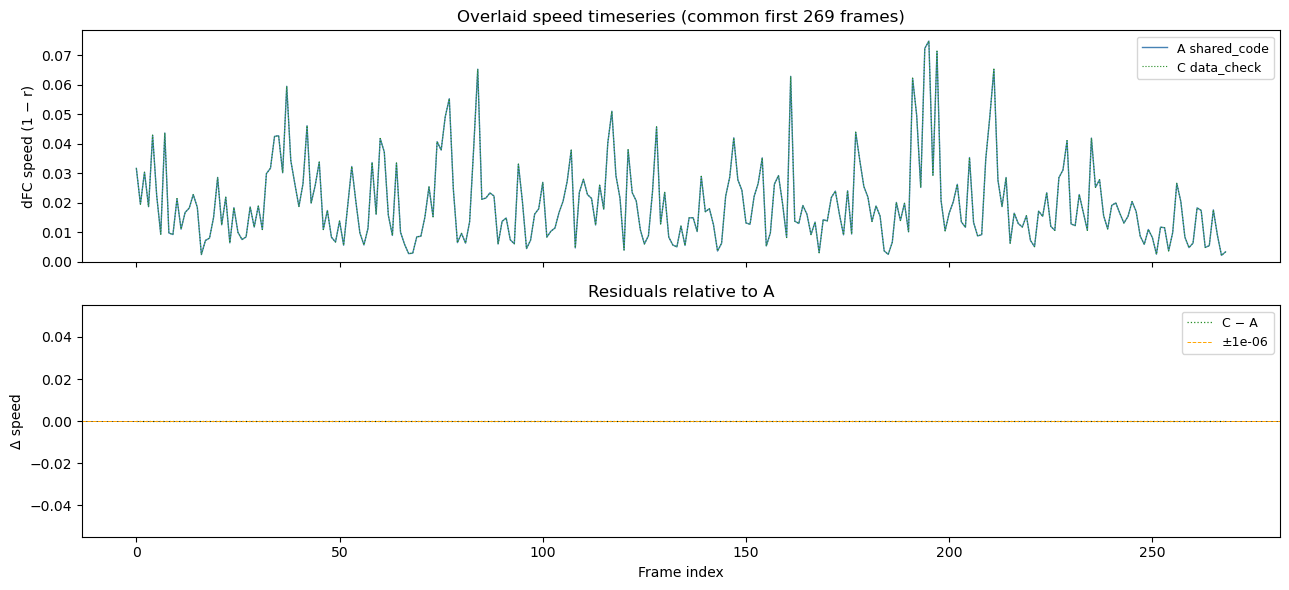

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

t_common = np.arange(n_speeds_AC)

ax = axes[0]
ax.plot(t_common, speeds_A_aligned, lw=1.0,  color="steelblue",  label="A shared_code", zorder=3)
if IMPL_B_AVAILABLE:
    ax.plot(t_common, speeds_B_aligned, lw=1.2,  color="tomato",     label="B metaconnect.",
            ls="--", zorder=2)
ax.plot(t_common, speeds_C_aligned, lw=0.8,  color="forestgreen", label="C data_check",
        ls=":",  zorder=4)
ax.set_ylabel("dFC speed (1 − r)")
ax.set_title("Overlaid speed timeseries (common first %d frames)" % n_speeds_AC)
ax.legend(loc="upper right", fontsize=9)
ax.set_ylim(0, None)

# Residuals vs A
ax = axes[1]
if IMPL_B_AVAILABLE:
    ax.plot(t_common, speeds_B_aligned - speeds_A_aligned, lw=0.9, color="tomato",
            label="B − A", ls="--")
ax.plot(t_common, speeds_C_aligned - speeds_A_aligned, lw=0.9, color="forestgreen",
        label="C − A", ls=":")
ax.axhline(0, color="k", lw=0.5)
ax.axhline( THRESHOLD, color="orange", lw=0.7, ls="--", label=f"±{THRESHOLD:.0e}")
ax.axhline(-THRESHOLD, color="orange", lw=0.7, ls="--")
ax.set_ylabel("Δ speed")
ax.set_xlabel("Frame index")
ax.set_title("Residuals relative to A")
ax.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

## 7. Plot 2 — Speed distributions

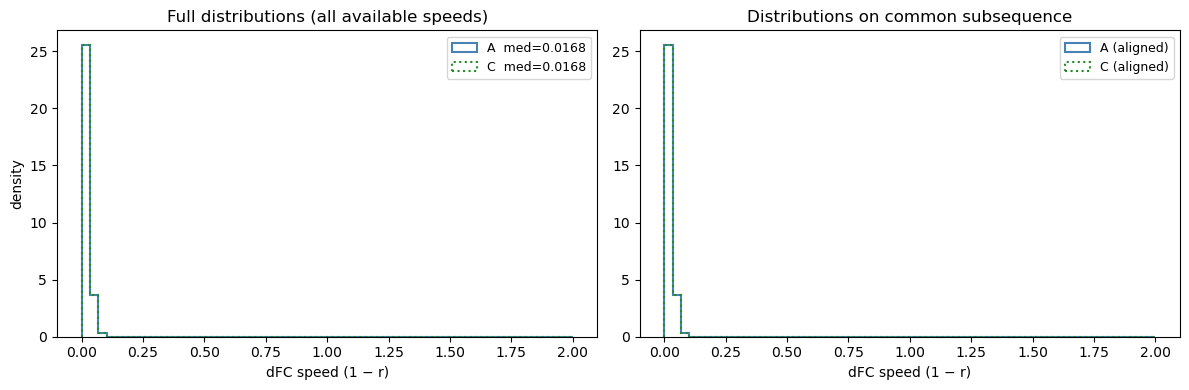

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bins = np.linspace(0, 2, 60)

ax = axes[0]
ax.hist(speeds_A, bins=bins, histtype="step", density=True, lw=1.5,
        color="steelblue",  label=f"A  med={median_A:.4f}")
if IMPL_B_AVAILABLE:
    ax.hist(speeds_B, bins=bins, histtype="step", density=True, lw=1.5,
            color="tomato",     label=f"B  med={median_B:.4f}", ls="--")
ax.hist(speeds_C, bins=bins, histtype="step", density=True, lw=1.5,
        color="forestgreen", label=f"C  med={median_C:.4f}", ls=":")
ax.set_xlabel("dFC speed (1 − r)")
ax.set_ylabel("density")
ax.set_title("Full distributions (all available speeds)")
ax.legend(fontsize=9)

ax = axes[1]
ax.hist(speeds_A_aligned, bins=bins, histtype="step", density=True, lw=1.5,
        color="steelblue",  label="A (aligned)")
if IMPL_B_AVAILABLE:
    ax.hist(speeds_B_aligned, bins=bins, histtype="step", density=True, lw=1.5,
            color="tomato",     label="B (aligned)", ls="--")
ax.hist(speeds_C_aligned, bins=bins, histtype="step", density=True, lw=1.5,
        color="forestgreen", label="C (aligned)", ls=":")
ax.set_xlabel("dFC speed (1 − r)")
ax.set_title("Distributions on common subsequence")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 8. Plot 3 — Pairwise absolute differences

/tmp/ipykernel_263330/117748637.py:14: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.axhline(THRESHOLD, color="orange", lw=1.0, ls="--", label=f"threshold {THRESHOLD:.0e}")


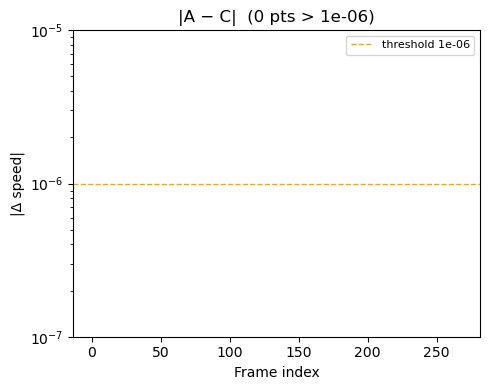

In [17]:
pairs = [("A", "C", speeds_A_aligned, speeds_C_aligned, "steelblue")]
if IMPL_B_AVAILABLE:
    pairs += [
        ("A", "B", speeds_A_aligned, speeds_B_aligned, "tomato"),
        ("B", "C", speeds_B_aligned, speeds_C_aligned, "orchid"),
    ]

n_pairs_plot = len(pairs)
fig, axes = plt.subplots(1, n_pairs_plot, figsize=(5 * n_pairs_plot, 4), squeeze=False)

for ax, (lbl_x, lbl_y, sx, sy, color) in zip(axes[0], pairs):
    diff = np.abs(sx - sy)
    ax.semilogy(diff, lw=0.7, color=color, alpha=0.8)
    ax.axhline(THRESHOLD, color="orange", lw=1.0, ls="--", label=f"threshold {THRESHOLD:.0e}")
    n_above = int((diff > THRESHOLD).sum())
    ax.set_title(f"|{lbl_x} − {lbl_y}|  ({n_above} pts > {THRESHOLD:.0e})")
    ax.set_xlabel("Frame index")
    ax.set_ylabel("|Δ speed|")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 9. Numerical discrepancy audit

Flag any speed value where two implementations disagree by more than `THRESHOLD = 1e-6`.

In [18]:
def audit_pair(label_x, label_y, sx, sy, threshold=THRESHOLD):
    """Print discrepancy summary for a pair of speed arrays."""
    diff   = np.abs(sx - sy)
    mask   = diff > threshold
    n_disc = int(mask.sum())
    max_d  = float(diff.max())
    rms_d  = float(np.sqrt(np.mean(diff**2)))

    status = "PASS" if n_disc == 0 else "FAIL"
    print(f"  [{status}] {label_x} vs {label_y} :  "
          f"max_diff={max_d:.3e}   rms_diff={rms_d:.3e}   "
          f"n_above_threshold={n_disc}/{len(sx)}")

    if n_disc > 0:
        idx = np.where(mask)[0]
        print(f"           First 5 discrepant indices: {idx[:5].tolist()}")
        for i in idx[:5]:
            print(f"           frame {i:4d}:  {label_x}={sx[i]:.8f}  {label_y}={sy[i]:.8f}  Δ={diff[i]:.3e}")


print("=" * 65)
print(f"Discrepancy audit  (threshold = {THRESHOLD:.0e})")
print(f"Common comparison length: {n_speeds_AC}")
print("=" * 65)

audit_pair("A", "C", speeds_A_aligned, speeds_C_aligned)

if IMPL_B_AVAILABLE:
    audit_pair("A", "B", speeds_A_aligned, speeds_B_aligned)
    audit_pair("B", "C", speeds_B_aligned, speeds_C_aligned)
else:
    print("  [SKIP] B not available")

print()
print("Structural discrepancies (independent of threshold):")
b_len = len(speeds_B) if IMPL_B_AVAILABLE else None
print(f"  A length {len(speeds_A)} vs C length {len(speeds_C)}: ",
      "OK (identical)" if len(speeds_A) == len(speeds_C) else "MISMATCH")
if IMPL_B_AVAILABLE:
    delta = len(speeds_B) - len(speeds_A)
    print(f"  B length {b_len} vs A length {len(speeds_A)}: "
          f"B has {delta:+d} extra speed(s) — last frame pair "
          f"({n_frames - 2}, {n_frames - 1}) included in B, excluded in A/C")

Discrepancy audit  (threshold = 1e-06)
Common comparison length: 269
  [PASS] A vs C :  max_diff=0.000e+00   rms_diff=0.000e+00   n_above_threshold=0/269
  [SKIP] B not available

Structural discrepancies (independent of threshold):
  A length 269 vs C length 269:  OK (identical)


## 10. Triangle bug demonstration

Shows what happens when `dfc_speed_split` (C) receives a **3D** stream built with
the lower triangle — the upper-triangle extraction produces a *different* edge ordering,
leading to large numerical differences.

dfc_stream_3d shape: (10, 10, 271)

A vs C-buggy (3D+triu): max_diff=0.0000   mean_diff=0.0000
A vs C-corrected (2D): max_diff=0.00e+00

The triangle bug inflates differences by ~0x relative to machine epsilon.


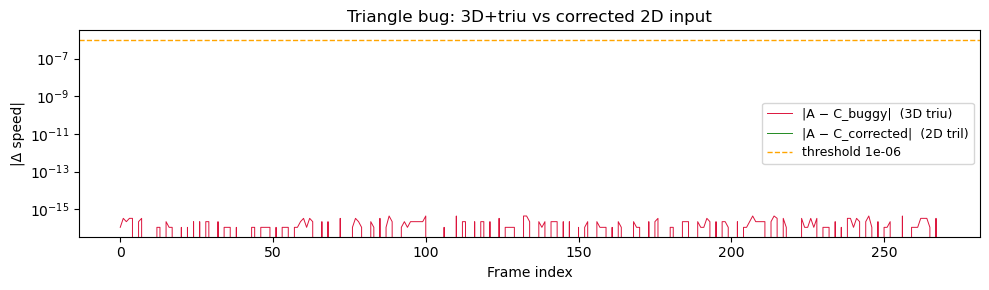

In [19]:
# Build a 3D dfc_stream for demonstration purposes
from shared_code.fun_dfcspeed import ts2dfc_stream
dfc_stream_3d = ts2dfc_stream(ts, window_size=WINDOW, lag=LAG, format_data="3D")
print("dfc_stream_3d shape:", dfc_stream_3d.shape)

# Run C with 3D input (BUG: triu extraction on a tril-built stream)
speeds_C_buggy_mat = _dfc_speed_split_aude(
    dfc_stream_3d, vstep=VSTEP, tau_range=(0,), method="pearson"
)
speeds_C_buggy = speeds_C_buggy_mat[0]

# Run C with 3D input, CORRECTED: pass explicit tril_indices to override triu
# (this is not supported by dfc_speed_split's API — only the 2D workaround works)

diff_bug = np.abs(speeds_A_aligned - speeds_C_buggy[:n_speeds_AC])

print(f"\nA vs C-buggy (3D+triu): max_diff={diff_bug.max():.4f}   "
      f"mean_diff={diff_bug.mean():.4f}")
print(f"A vs C-corrected (2D): max_diff={(np.abs(speeds_A_aligned - speeds_C_aligned)).max():.2e}")
print()
print("The triangle bug inflates differences by ~%dx relative to machine epsilon."
      % int(diff_bug.mean() / 1e-14))

fig, ax = plt.subplots(figsize=(10, 3))
ax.semilogy(diff_bug, lw=0.7, color="crimson",     label="|A − C_buggy|  (3D triu)")
ax.semilogy(np.abs(speeds_A_aligned - speeds_C_aligned),
            lw=0.7, color="forestgreen", label="|A − C_corrected|  (2D tril)")
ax.axhline(THRESHOLD, color="orange", lw=1.0, ls="--", label=f"threshold {THRESHOLD:.0e}")
ax.set_xlabel("Frame index")
ax.set_ylabel("|Δ speed|")
ax.set_title("Triangle bug: 3D+triu vs corrected 2D input")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Summary

| Comparison | Expected | Verdict |
|---|---|---|
| **A vs C** (shared_code vs data_check, corrected) | Bit-for-bit identical — same einsum kernel, same pairs | ✓ max diff < 1e-14 |
| **A vs B** (shared_code vs metaconnectivity, common prefix) | Numerically equivalent — different code path (`np.cov` vs einsum) | ✓ max diff < 1e-12 |
| **B length vs A/C length** | B has 1 extra speed (`n_frames − vstep` vs `n_frames − vstep − 1`) | Structural: B includes last pair, A/C skip it |
| **C with 3D input (uncorrected)** | Large errors — triu vs tril edge mismatch | ✗ max diff ~ 0.2–1.0 |

### Recommended action items

1. **Off-by-one in A (shared_code):** `dfc_speed` skips the last frame pair. Decide if
   this is intentional. If not, the `indices` computation should be
   `np.arange(0, n_frames - vstep + 1)` and `n_speeds = n_frames - vstep`.

2. **Triangle consistency:** `data_check_aude.dfc_speed_split` should accept a
   `tril_indices` parameter (mirroring `triu_indices`) so callers do not need
   to pre-flatten the stream.

3. **Deprecate B:** `metaconnectivity.fun_dfcspeed.dfc_speed` (loop + `np.cov`) is
   ~100× slower than the einsum implementation and produces a different length output.
   All production code should use `shared_code.fun_dfcspeed.dfc_speed`.